In [1]:
# -*- coding: utf-8 -*-

# Proyecto: Mining Supply Chain Decision Intelligence

# Notebook 04 - Reinforcement Learning (RL)

### Objetivo
--------
Construir un entorno de decisión (environment) para supply chain y entrenar
un agente de aprendizaje por refuerzo que optimice decisiones de reabastecimiento.

### Qué incluye este notebook
-------------------------
1) Carga de datos procesados + scoring del modelo supervisado
2) Definición del entorno RL (estado, acción, reward)
3) Implementación de un entorno tipo Gym
4) Entrenamiento de un agente (DQN)
5) Evaluación del agente vs políticas baseline
6) Exportación del agente y resultados

### Diseño conceptual
-----------------
Estado (state):
- stock actual
- demanda histórica (lags)
- riesgo predicho (modelo supervisado)
- clima
- lead time aproximado

Acción (action):
- cantidad a ordenar (discreta)

Reward:
- penaliza stockout (muy fuerte)
- penaliza exceso de inventario
- penaliza costo total
- recompensa buen nivel de servicio

Desarrollado y pensado para ejecutarse en Google Colab.

In [2]:
# =========================================================
# 1) Imports.
# =========================================================

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from __future__ import annotations

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Ejecutando en: {device}")

Ejecutando en: cpu


In [3]:
# =========================================================
# 2) Configuracion de rutas.
# =========================================================

CURRENT_DIR = Path.cwd()
PROJECT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
MODELS_DIR = PROJECT_DIR / "models"

for folder in [PROCESSED_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)
    
print("Proyecto configurado localmente en:", PROJECT_DIR)

Proyecto configurado localmente en: c:\Users\acer\Documents\PYTHON\Portfolio\02 Mining Supply Chain Decision Intelligence


In [4]:
# =========================================================
# 3) Carga de datos.
# =========================================================

print("Cargando datos...")

df = pd.read_csv(PROCESSED_DIR / "feature_engineered_dataset.csv", parse_dates=["date"])
scoring_df = pd.read_csv(PROCESSED_DIR / "model_scoring_dataset.csv", parse_dates=["date"])

# Merge para incorporar riesgo predicho
df = df.merge(
    scoring_df[["date", "mine_id", "item_id", "predicted_stockout_proba_next_day"]],
    on=["date", "mine_id", "item_id"],
    how="left"
)

Cargando datos...


In [5]:
# =========================================================
# 4) Entorno RL.
# =========================================================

class SupplyChainEnv:
    def __init__(self, data: pd.DataFrame, max_order=500):
        self.data = data.sort_values("date").reset_index(drop=True)
        self.max_order = max_order
        self.current_step = 0

    def reset(self):
        self.current_step = 0
        return self._get_state()

    def _get_state(self):
        row = self.data.iloc[self.current_step]
        return np.array([
            row["ending_stock"],
            row["demand_units"],
            row.get("demand_lag_1", 0),
            row.get("demand_roll_mean_7", 0),
            row.get("predicted_stockout_proba_next_day", 0),
            row.get("risk_score", 0),
        ], dtype=np.float32)
    def step(self, action):
        row = self.data.iloc[self.current_step]

        order_qty = action
        demand = row["demand_units"]
        stock = row["ending_stock"] + order_qty

        sales = min(stock, demand)
        stock -= sales

        stockout = max(0, demand - sales)

        # Reward
        reward = 0
        reward -= stockout * 10
        reward -= stock * 0.1
        reward -= order_qty * 0.05
        reward += sales * 0.2

        self.current_step += 1
        done = self.current_step >= len(self.data) - 1

        next_state = self._get_state() if not done else None

        return next_state, reward, done

In [6]:
# =========================================================
# 5) DQN.
# =========================================================

class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_dim)
        )

    def forward(self, x):
        return self.net(x)

In [7]:
# =========================================================
# 6) Entrenamiento.
# =========================================================

state_dim = 6
action_space = [0, 50, 100, 200, 300, 400]
action_dim = len(action_space)

model = DQN(state_dim, action_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

memory = deque(maxlen=5000)

def select_action(state, epsilon=0.1):
    if random.random() < epsilon:
        return random.randrange(action_dim)
    state_t = torch.tensor(state).float().unsqueeze(0)
    q_values = model(state_t)
    return torch.argmax(q_values).item()


def train_step(batch_size=32, gamma=0.99):
    if len(memory) < batch_size:
        return
    
    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)
    
    # Convertimos la tupla/lista a un np.array antes de crear el tensor.
    # Esto asigna un solo bloque de memoria.
    states = torch.tensor(np.array(states)).float()

    # actions debe ser un tensor de enteros (long) para usarlo con .gather()
    actions = torch.tensor(np.array(actions)).long()
    
    rewards = torch.tensor(np.array(rewards)).float()
    
    # Filtramos los next_states nulos y agrupamos en Numpy.
    valid_next_states = [s for s in next_states if s is not None]
    next_states = torch.tensor(np.array(valid_next_states)).float()
    
    q_values = model(states)
    q_value = q_values.gather(1, actions.unsqueeze(1)).squeeze()
    
    next_q = torch.zeros(len(batch))
    if len(valid_next_states) > 0:
        next_q[:len(valid_next_states)] = model(next_states).max(1)[0].detach()
    
    target = rewards + gamma * next_q
    
    loss = loss_fn(q_value, target)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [8]:
# =========================================================
# 7) Loop de entrenamiento.
# =========================================================

env = SupplyChainEnv(df.sample(5000))

episodes = 30
rewards_history = []

for ep in range(episodes):
    state = env.reset()
    total_reward = 0

    while True:
        action_idx = select_action(state, epsilon=0.2)
        action = action_space[action_idx]

        next_state, reward, done = env.step(action)

        memory.append((state, action_idx, reward, next_state, done))
        train_step()

        state = next_state
        total_reward += reward

        if done:
            break

    rewards_history.append(total_reward)
    print(f"Episode {ep+1}: Reward = {total_reward:.2f}")

Episode 1: Reward = -217662.70
Episode 2: Reward = -205305.40
Episode 3: Reward = -203094.40
Episode 4: Reward = -201440.80
Episode 5: Reward = -201505.60
Episode 6: Reward = -200584.30
Episode 7: Reward = -204621.80
Episode 8: Reward = -206164.10
Episode 9: Reward = -202409.30
Episode 10: Reward = -205558.00
Episode 11: Reward = -203475.60
Episode 12: Reward = -206549.80
Episode 13: Reward = -203864.40
Episode 14: Reward = -205550.60
Episode 15: Reward = -203426.00
Episode 16: Reward = -203979.30
Episode 17: Reward = -206566.00
Episode 18: Reward = -203951.70
Episode 19: Reward = -206183.50
Episode 20: Reward = -202524.30
Episode 21: Reward = -205117.30
Episode 22: Reward = -202315.30
Episode 23: Reward = -204596.90
Episode 24: Reward = -205828.80
Episode 25: Reward = -203706.00
Episode 26: Reward = -203914.70
Episode 27: Reward = -202285.00
Episode 28: Reward = -202398.60
Episode 29: Reward = -204243.80
Episode 30: Reward = -203914.00


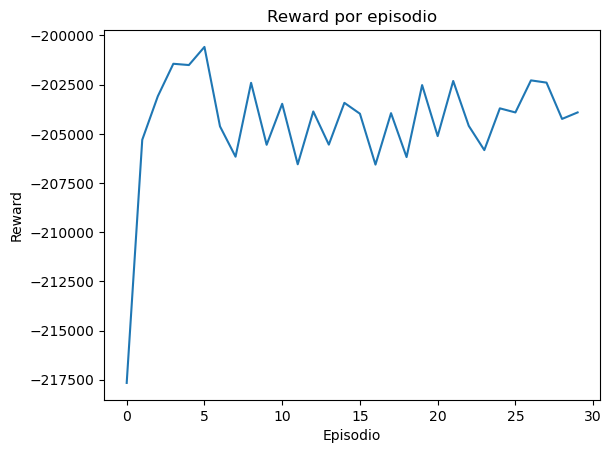

In [9]:
# =========================================================
# 8) Evaluacion.
# =========================================================

plt.plot(rewards_history)
plt.title("Reward por episodio")
plt.xlabel("Episodio")
plt.ylabel("Reward")
plt.show()

In [10]:
# =========================================================
# 9) Guardado.
# =========================================================

print("Guardando pesos del agente DQN...")
torch.save(model.state_dict(), MODELS_DIR / "dqn_supply_chain_agent.pth")
print("Agente guardado exitosamente.")

Guardando pesos del agente DQN...
Agente guardado exitosamente.
